786
688
    ID    version   HIP      TYC      ... raddflag wdflag   objID  
--------- -------- ----- ------------ ... -------- ------ ---------
233087860 20190415    -- 4201-01875-1 ...        1      0 185679889
355895977 20190415    --           -- ...        1      0 146551972
155012162 20190415    -- 1403-01018-1 ...        1      0 138354365
460984940 20190415    -- 8961-01933-1 ...        1      0 722275056
120183168 20190415    -- 3119-00568-1 ...        1      0 229799590
289580577 20190415    -- 4191-00694-1 ...        1      0 163819546
388898854 20190415    -- 0860-00737-1 ...        1      0 143753453
 68646526 20190415    -- 1288-00318-1 ...        1      0  70489997
178155732 20190415 13363 7012-00833-1 ...        1      0 519787430
121731834 20190415    -- 3125-00976-1 ...        1      0 260745275
      ...      ...   ...          ... ...      ...    ...       ...
407126408 20190415    -- 9441-00843-1 ...        1      0 988489484
  4897275 20190415 48443 2508-01256-1 ..

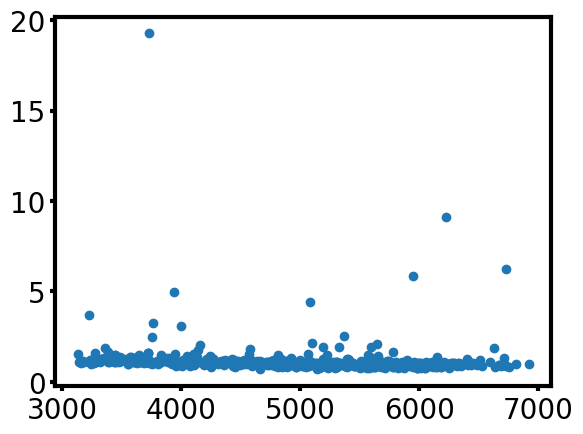

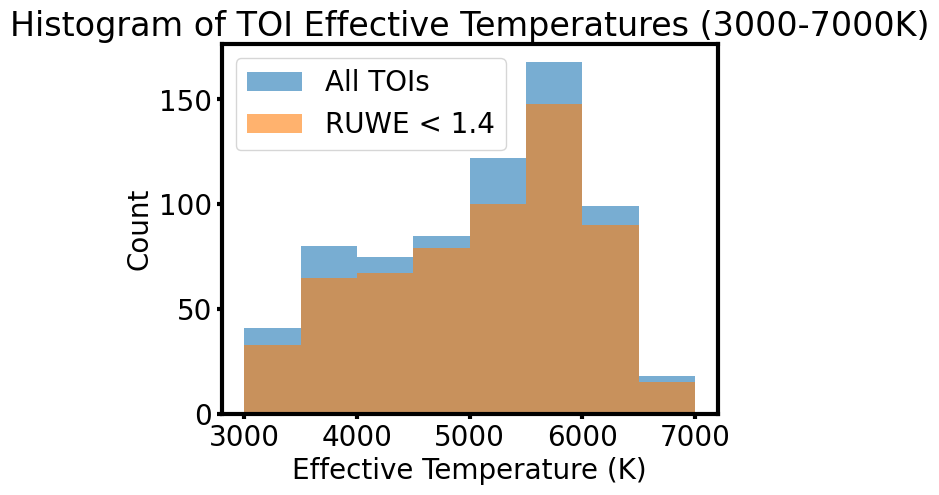

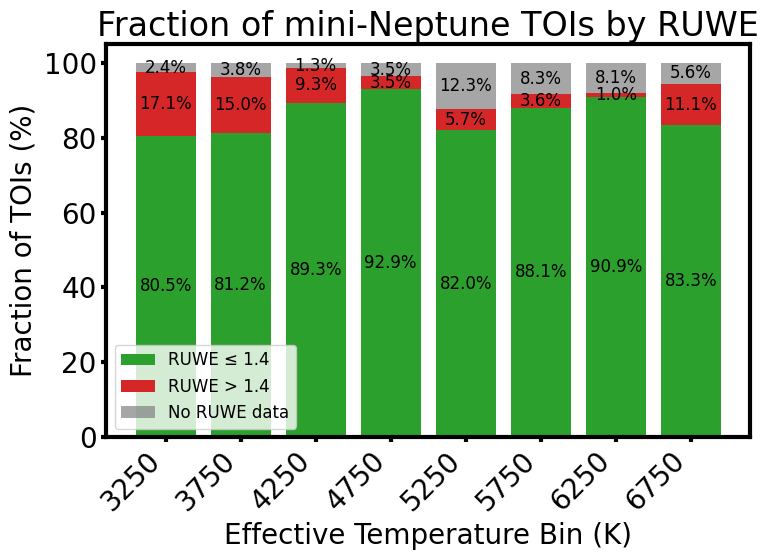

Saved: TOI_Mar2025_ruwe_teff_fraction.png


In [2]:
import pandas as pd
from astroquery.mast import Catalogs
from astroquery.gaia import Gaia
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


plt.rcParams.update({'lines.linewidth': 3, 'axes.linewidth': 3, 'grid.linewidth': 3, 'xtick.major.width': 3, 'ytick.major.width': 3, 'xtick.minor.width': 3, 'ytick.minor.width': 3})
plt.rcParams.update({'font.size': 20})

TOIs = pd.read_csv("TOI_Mar2025_1pt5to4_R_detected_real_only.csv")
print(len(TOIs))
# Ensure numeric columns (safe if values were read as strings)
TOIs['pl_rade'] = pd.to_numeric(TOIs['pl_rade'], errors='coerce')
TOIs['pl_orbper'] = pd.to_numeric(TOIs['pl_orbper'], errors='coerce')

TOIs = TOIs[(TOIs['pl_rade'] < 4.0) & (TOIs['pl_rade'] > 1.8)]
TOIs = TOIs[(TOIs['pl_orbper'] < 25) & (TOIs['pl_orbper'] > 0.531)]
print(len(TOIs))
tic_ids = TOIs['id'].astype(int).unique().tolist()

# Get Gaia IDs from TIC
all_results = []

result = Catalogs.query_criteria(catalog="Tic", ID=tic_ids)
print(result)

all_results.append(result.to_pandas()[['ID', 'GAIA']])


gaia_df = pd.concat(all_results, ignore_index=True).dropna(subset=['GAIA'])
gaia_ids = gaia_df['GAIA'].astype(int).tolist()

# Query Gaia for RUWE
query = f"SELECT source_id, ruwe FROM gaiadr3.gaia_source WHERE source_id IN ({','.join(map(str, gaia_ids))})"
job = Gaia.launch_job(query)
ruwe_df = job.get_results().to_pandas()
print(ruwe_df)

# Merge everything using proper joins on IDs (not row position)
# First merge TOIs with Gaia IDs on TIC ID
gaia_df = gaia_df.rename(columns={'ID': 'id'})  # Match TOI column name
gaia_df['id'] = gaia_df['id'].astype(int)  # Ensure matching type
TOIs_with_gaia = TOIs.merge(gaia_df[['id', 'GAIA']], on='id', how='left')

# Then merge with RUWE on Gaia source_id
ruwe_df = ruwe_df.rename(columns={'SOURCE_ID': 'GAIA'})
ruwe_df['GAIA'] = ruwe_df['GAIA'].astype(str)  # Convert to string
TOIs_with_gaia['GAIA'] = TOIs_with_gaia['GAIA'].astype(str)  # Convert to string
TOIs_with_gaia = TOIs_with_gaia.merge(ruwe_df[['GAIA', 'ruwe']], on='GAIA', how='left')

print(f"Total: {len(TOIs_with_gaia)}, With Gaia ID: {TOIs_with_gaia['GAIA'].notna().sum()}, With RUWE: {TOIs_with_gaia['ruwe'].notna().sum()}")
print(TOIs_with_gaia.head(10))

plt.plot(TOIs_with_gaia['st_teff'], TOIs_with_gaia['ruwe'], 'o')

print('number of tois with ruwe > 1.4 ', TOIs_with_gaia[TOIs_with_gaia['ruwe'] > 1.4].shape[0])
# Save the dataframe with the new RUWE column to a new CSV file
TOIs_with_gaia.to_csv("TOI_Mar2025_1pt5to4_R_with_ruwe.csv", index=False)

# Histogram of all TOIs
plt.figure()
plt.hist(TOIs_with_gaia['st_teff'].dropna(), bins=8, range=(3000, 7000), alpha=0.6, label='All TOIs')

# Histogram of TOIs with RUWE < 1.4
plt.hist(TOIs_with_gaia.loc[TOIs_with_gaia['ruwe'] < 1.4, 'st_teff'].dropna(), 
         bins=8, range=(3000, 7000), alpha=0.6, label='RUWE < 1.4')

plt.xlabel('Effective Temperature (K)')
plt.ylabel('Count')
plt.title('Histogram of TOI Effective Temperatures (3000-7000K)')
plt.legend()
plt.show()

# Calculate counts per Teff bin for RUWE ≤ 1.4 and RUWE > 1.4
teff = TOIs_with_gaia['st_teff']
ruwe = TOIs_with_gaia['ruwe']

bins = np.array([3000., 3500., 4000., 4500., 5000., 5500., 6000., 6500., 7000.])
bin_centers = (bins[:-1] + bins[1:]) / 2
bar_width = bins[1] - bins[0]
# Calculate counts per Teff bin for RUWE ≤ 1.4, RUWE > 1.4, and missing RUWE
teff = TOIs_with_gaia['st_teff']
ruwe = TOIs_with_gaia['ruwe']

bins = np.array([3000., 3500., 4000., 4500., 5000., 5500., 6000., 6500., 7000.])
bin_centers = (bins[:-1] + bins[1:]) / 2
bar_width = bins[1] - bins[0]

mask_teff = teff.notna()
mask_le = mask_teff & (ruwe <= 1.4)
mask_gt = mask_teff & (ruwe > 1.4)
mask_na = mask_teff & (ruwe.isna())

ruwe_le_hist, _ = np.histogram(teff[mask_le], bins=bins)
ruwe_gt_hist, _ = np.histogram(teff[mask_gt], bins=bins)
ruwe_na_hist, _ = np.histogram(teff[mask_na], bins=bins)
all_hist, _ = np.histogram(teff[mask_teff], bins=bins)

# Safe fractions
frac_le = np.divide(ruwe_le_hist, all_hist, out=np.zeros_like(ruwe_le_hist, dtype=float), where=all_hist > 0)
frac_gt = np.divide(ruwe_gt_hist, all_hist, out=np.zeros_like(ruwe_gt_hist, dtype=float), where=all_hist > 0)
frac_na = np.divide(ruwe_na_hist, all_hist, out=np.zeros_like(ruwe_na_hist, dtype=float), where=all_hist > 0)

# Stacked bar chart
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(bin_centers, frac_le * 100, width=bar_width * 0.8, label='RUWE ≤ 1.4', color='tab:green', alpha=1)
ax.bar(bin_centers, frac_gt * 100, width=bar_width * 0.8, bottom=frac_le * 100, label='RUWE > 1.4', color='tab:red', alpha=1)
ax.bar(
    bin_centers,
    frac_na * 100,
    width=bar_width * 0.8,
    bottom=(frac_le + frac_gt) * 100,
    label='No RUWE data',
    color='gray',
    alpha=0.7
)

# Percentage labels
for x, y_le, y_gt, y_na in zip(bin_centers, frac_le, frac_gt, frac_na):
    if y_le > 0:
        ax.text(x, (y_le * 100) / 2, f"{y_le * 100:.1f}%", ha='center', va='center', color='black', fontsize=12)
    if y_gt > 0:
        ax.text(x, (y_le + y_gt / 2) * 100, f"{y_gt * 100:.1f}%", ha='center', va='center', color='black', fontsize=12)
    if y_na > 0:
        ax.text(x, (y_le + y_gt + y_na / 2) * 100, f"{y_na * 100:.1f}%", ha='center', va='center', color='black', fontsize=12)

ax.set_xlabel('Effective Temperature Bin (K)')
ax.set_ylabel('Fraction of TOIs (%)')
ax.set_title('Fraction of mini-Neptune TOIs by RUWE')
ax.set_xticks(bin_centers)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xticklabels([f"{int(b)}" for b in bin_centers])
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()
# Save the stacked RUWE-vs-Teff fraction plot as PNG
fig.savefig("TOI_Mar2025_ruwe_teff_fraction.png", dpi=300, bbox_inches="tight")
print("Saved: TOI_Mar2025_ruwe_teff_fraction.png")

39746
39746
    ID     version   HIP       TYC      ... raddflag wdflag   objID   
---------- -------- ------ ------------ ... -------- ------ ----------
 305300554 20190415     -- 2729-00047-1 ...        1      0  458593458
 120046790 20190415  92916           -- ...        1      0  227709864
   7854956 20190415     -- 3525-01887-1 ...        1      0  193883134
 401868996 20190415     -- 8041-00716-1 ...        1      0  516831845
 219038788 20190415  67691 3467-00367-1 ...        1      0  149851715
   5012965 20190415     -- 2526-01989-1 ...        1      0  143968881
  13623488 20190415     -- 5443-00002-1 ...        1      0  656052152
 288959702 20190415     -- 2636-01836-1 ...        1      0  197977680
 387809195 20190415 103650 4464-00648-1 ...        1      0  431625808
 247451741 20190415     -- 8327-01658-1 ...        1      0 1139533437
       ...      ...    ...          ... ...      ...    ...        ...
 119875474 20190415  90945 8745-01216-1 ...        1      0 15414

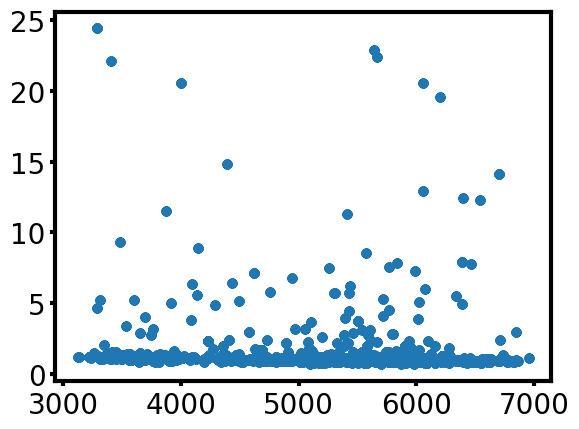

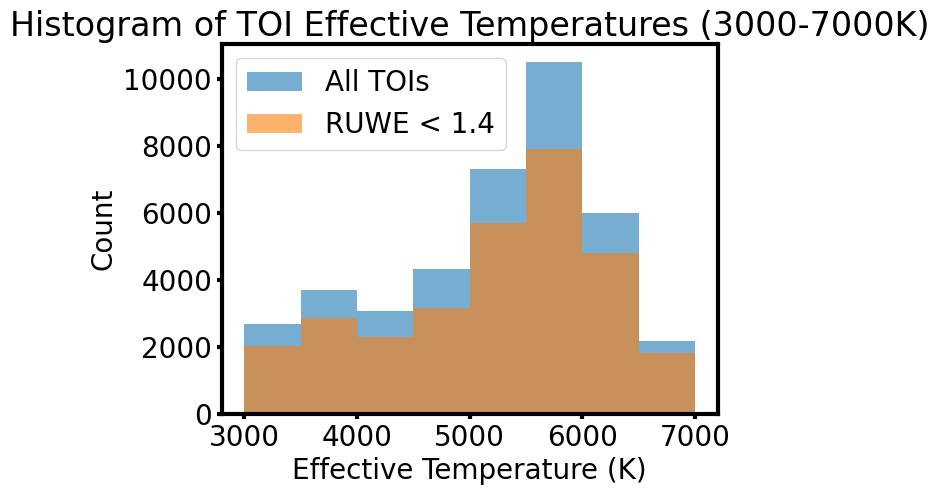

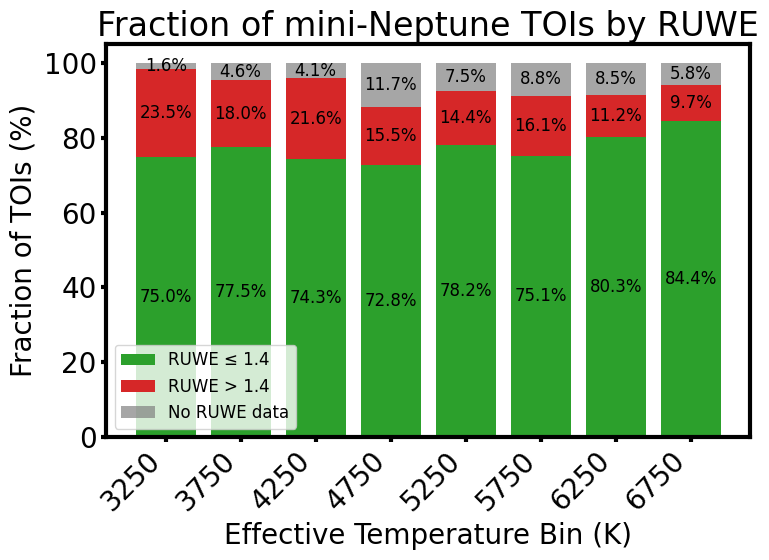

Saved: control_Mar2025_ruwe_teff_fraction.png


In [3]:
import pandas as pd
from astroquery.mast import Catalogs
from astroquery.gaia import Gaia
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

TOIs = pd.read_csv("take_two_tls_output_combined.csv")
print(len(TOIs))
# Ensure numeric columns (safe if values were read as strings)
# TOIs['pl_rade'] = pd.to_numeric(TOIs['pl_rade'], errors='coerce')
# TOIs['pl_orbper'] = pd.to_numeric(TOIs['pl_orbper'], errors='coerce')

# TOIs = TOIs[(TOIs['pl_rade'] < 4.0) & (TOIs['pl_rade'] > 1.8)]
# TOIs = TOIs[(TOIs['pl_orbper'] < 25) & (TOIs['pl_orbper'] > 0.531)]
print(len(TOIs))
TOIs['id'] = (
    TOIs['TIC']
    .astype(str)
    .str.replace(r'^\s*TIC\s*', '', regex=True)
    .str.strip()
    .astype(int)
)
# Remove leading "TIC" text and build numeric TIC IDs

tic_ids = TOIs['id'].unique().tolist()

# Get Gaia IDs from TIC
all_results = []

result = Catalogs.query_criteria(catalog="Tic", ID=tic_ids)
print(result)

all_results.append(result.to_pandas()[['ID', 'GAIA']])


gaia_df = pd.concat(all_results, ignore_index=True).dropna(subset=['GAIA'])
gaia_ids = gaia_df['GAIA'].astype(int).tolist()

# Query Gaia for RUWE
query = f"SELECT source_id, ruwe FROM gaiadr3.gaia_source WHERE source_id IN ({','.join(map(str, gaia_ids))})"
job = Gaia.launch_job(query)
ruwe_df = job.get_results().to_pandas()
print(ruwe_df)

# Merge everything using proper joins on IDs (not row position)
# First merge TOIs with Gaia IDs on TIC ID
gaia_df = gaia_df.rename(columns={'ID': 'id'})  # Match TOI column name
gaia_df['id'] = gaia_df['id'].astype(int)  # Ensure matching type
TOIs_with_gaia = TOIs.merge(gaia_df[['id', 'GAIA']], on='id', how='left')

# Then merge with RUWE on Gaia source_id
ruwe_df = ruwe_df.rename(columns={'SOURCE_ID': 'GAIA'})
ruwe_df['GAIA'] = ruwe_df['GAIA'].astype(str)  # Convert to string
TOIs_with_gaia['GAIA'] = TOIs_with_gaia['GAIA'].astype(str)  # Convert to string
TOIs_with_gaia = TOIs_with_gaia.merge(ruwe_df[['GAIA', 'ruwe']], on='GAIA', how='left')

print(f"Total: {len(TOIs_with_gaia)}, With Gaia ID: {TOIs_with_gaia['GAIA'].notna().sum()}, With RUWE: {TOIs_with_gaia['ruwe'].notna().sum()}")
print(TOIs_with_gaia.head(10))

plt.plot(TOIs_with_gaia['Stellar Temperature'], TOIs_with_gaia['ruwe'], 'o')

print('number of tois with ruwe > 1.4 ', TOIs_with_gaia[TOIs_with_gaia['ruwe'] > 1.4].shape[0])
# Save the dataframe with the new RUWE column to a new CSV file
TOIs_with_gaia.to_csv("TOI_Mar2025_1pt5to4_R_with_ruwe.csv", index=False)

# Histogram of all TOIs
plt.figure()
plt.hist(TOIs_with_gaia['Stellar Temperature'].dropna(), bins=8, range=(3000, 7000), alpha=0.6, label='All TOIs')

# Histogram of TOIs with RUWE < 1.4
plt.hist(TOIs_with_gaia.loc[TOIs_with_gaia['ruwe'] < 1.4, 'Stellar Temperature'].dropna(), 
         bins=8, range=(3000, 7000), alpha=0.6, label='RUWE < 1.4')

plt.xlabel('Effective Temperature (K)')
plt.ylabel('Count')
plt.title('Histogram of TOI Effective Temperatures (3000-7000K)')
plt.legend()
plt.show()

# Calculate counts per Teff bin for RUWE ≤ 1.4 and RUWE > 1.4
teff = TOIs_with_gaia['Stellar Temperature']
ruwe = TOIs_with_gaia['ruwe']

bins = np.array([3000., 3500., 4000., 4500., 5000., 5500., 6000., 6500., 7000.])
bin_centers = (bins[:-1] + bins[1:]) / 2
bar_width = bins[1] - bins[0]
# Calculate counts per Teff bin for RUWE ≤ 1.4, RUWE > 1.4, and missing RUWE
teff = TOIs_with_gaia['Stellar Temperature']
ruwe = TOIs_with_gaia['ruwe']

bins = np.array([3000., 3500., 4000., 4500., 5000., 5500., 6000., 6500., 7000.])
bin_centers = (bins[:-1] + bins[1:]) / 2
bar_width = bins[1] - bins[0]

mask_teff = teff.notna()
mask_le = mask_teff & (ruwe <= 1.4)
mask_gt = mask_teff & (ruwe > 1.4)
mask_na = mask_teff & (ruwe.isna())

ruwe_le_hist, _ = np.histogram(teff[mask_le], bins=bins)
ruwe_gt_hist, _ = np.histogram(teff[mask_gt], bins=bins)
ruwe_na_hist, _ = np.histogram(teff[mask_na], bins=bins)
all_hist, _ = np.histogram(teff[mask_teff], bins=bins)

# Safe fractions
frac_le = np.divide(ruwe_le_hist, all_hist, out=np.zeros_like(ruwe_le_hist, dtype=float), where=all_hist > 0)
frac_gt = np.divide(ruwe_gt_hist, all_hist, out=np.zeros_like(ruwe_gt_hist, dtype=float), where=all_hist > 0)
frac_na = np.divide(ruwe_na_hist, all_hist, out=np.zeros_like(ruwe_na_hist, dtype=float), where=all_hist > 0)

# Stacked bar chart
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(bin_centers, frac_le * 100, width=bar_width * 0.8, label='RUWE ≤ 1.4', color='tab:green', alpha=1)
ax.bar(bin_centers, frac_gt * 100, width=bar_width * 0.8, bottom=frac_le * 100, label='RUWE > 1.4', color='tab:red', alpha=1)
ax.bar(
    bin_centers,
    frac_na * 100,
    width=bar_width * 0.8,
    bottom=(frac_le + frac_gt) * 100,
    label='No RUWE data',
    color='gray',
    alpha=0.7
)

# Percentage labels
for x, y_le, y_gt, y_na in zip(bin_centers, frac_le, frac_gt, frac_na):
    if y_le > 0:
        ax.text(x, (y_le * 100) / 2, f"{y_le * 100:.1f}%", ha='center', va='center', color='black', fontsize=12)
    if y_gt > 0:
        ax.text(x, (y_le + y_gt / 2) * 100, f"{y_gt * 100:.1f}%", ha='center', va='center', color='black', fontsize=12)
    if y_na > 0:
        ax.text(x, (y_le + y_gt + y_na / 2) * 100, f"{y_na * 100:.1f}%", ha='center', va='center', color='black', fontsize=12)

ax.set_xlabel('Effective Temperature Bin (K)')
ax.set_ylabel('Fraction of TOIs (%)')
ax.set_title('Fraction of mini-Neptune TOIs by RUWE')
ax.set_xticks(bin_centers)
ax.set_xticklabels([f"{int(b)}" for b in bin_centers])
ax.legend(fontsize=12)
ax.set_xticklabels([f"{int(b)}" for b in bin_centers])
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()
# Save the stacked RUWE-vs-Teff fraction plot as PNG
fig.savefig("control_Mar2025_ruwe_teff_fraction.png", dpi=300, bbox_inches="tight")
print("Saved: control_Mar2025_ruwe_teff_fraction.png")

In [4]:
import pandas as pd
from astroquery.mast import Catalogs
from astroquery.gaia import Gaia
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

TOIs = pd.read_csv("TOI_Mar2025_1pt5to4_R_detected_real_only.csv")
print(len(TOIs))
# Ensure numeric columns (safe if values were read as strings)
TOIs['pl_rade'] = pd.to_numeric(TOIs['pl_rade'], errors='coerce')
TOIs['pl_orbper'] = pd.to_numeric(TOIs['pl_orbper'], errors='coerce')

TOIs = TOIs[(TOIs['pl_rade'] < 4.0) & (TOIs['pl_rade'] > 1.8)]
TOIs = TOIs[(TOIs['pl_orbper'] < 25) & (TOIs['pl_orbper'] > 0.531)]
print(len(TOIs))
tic_ids = TOIs['id'].astype(int).unique().tolist()

# Get Gaia IDs from TIC
all_results = []

result = Catalogs.query_criteria(catalog="Tic", ID=tic_ids)
print(result.columns)

print(result['Teff'])
# Calculate counts per Teff bin for RUWE ≤ 1.4 and RUWE > 1.4
teff = result['Teff'].astype(float) 
ruwe = result['ruwe'].astype(float)



bins = np.array([3000., 3500., 4000., 4500., 5000., 5500., 6000., 6500., 7000.])
bin_centers = (bins[:-1] + bins[1:]) / 2
bar_width = bins[1] - bins[0]

mask_teff = teff.notna()
mask_le = mask_teff & (ruwe <= 1.4)
mask_gt = mask_teff & (ruwe > 1.4)
mask_na = mask_teff & (ruwe.isna())

ruwe_le_hist, _ = np.histogram(teff[mask_le], bins=bins)
ruwe_gt_hist, _ = np.histogram(teff[mask_gt], bins=bins)
ruwe_na_hist, _ = np.histogram(teff[mask_na], bins=bins)
all_hist, _ = np.histogram(teff[mask_teff], bins=bins)

# Safe fractions
frac_le = np.divide(ruwe_le_hist, all_hist, out=np.zeros_like(ruwe_le_hist, dtype=float), where=all_hist > 0)
frac_gt = np.divide(ruwe_gt_hist, all_hist, out=np.zeros_like(ruwe_gt_hist, dtype=float), where=all_hist > 0)
frac_na = np.divide(ruwe_na_hist, all_hist, out=np.zeros_like(ruwe_na_hist, dtype=float), where=all_hist > 0)

# Stacked bar chart
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(bin_centers, frac_le * 100, width=bar_width * 0.8, label='RUWE ≤ 1.4', color='tab:blue', alpha=0.7)
ax.bar(bin_centers, frac_gt * 100, width=bar_width * 0.8, bottom=frac_le * 100, label='RUWE > 1.4', color='tab:orange', alpha=0.7)
ax.bar(
    bin_centers,
    frac_na * 100,
    width=bar_width * 0.8,
    bottom=(frac_le + frac_gt) * 100,
    label='No RUWE data',
    color='gray',
    alpha=0.7
)

# Percentage labels
for x, y_le, y_gt, y_na in zip(bin_centers, frac_le, frac_gt, frac_na):
    if y_le > 0:
        ax.text(x, (y_le * 100) / 2, f"{y_le * 100:.1f}%", ha='center', va='center', color='white', fontsize=9)
    if y_gt > 0:
        ax.text(x, (y_le + y_gt / 2) * 100, f"{y_gt * 100:.1f}%", ha='center', va='center', color='black', fontsize=9)
    if y_na > 0:
        ax.text(x, (y_le + y_gt + y_na / 2) * 100, f"{y_na * 100:.1f}%", ha='center', va='center', color='white', fontsize=9)

ax.set_xlabel('Effective Temperature Bin (K)')
ax.set_ylabel('Fraction of TOIs (%)')
ax.set_title('Fraction of mini-Neptune TOIs by RUWE category per Teff Bin')
ax.set_xticks(bin_centers)
ax.set_xticklabels([f"{int(b)}" for b in bin_centers])
ax.legend()
plt.tight_layout()
plt.show()
# Save the stacked RUWE-vs-Teff fraction plot as PNG
fig.savefig("TOI_Mar2025_ruwe_teff_fraction.png", dpi=300, bbox_inches="tight")
print("Saved: TOI_Mar2025_ruwe_teff_fraction.png")

786
688
<TableColumns names=('ID','version','HIP','TYC','UCAC','TWOMASS','SDSS','ALLWISE','GAIA','APASS','KIC','objType','typeSrc','ra','dec','POSflag','pmRA','e_pmRA','pmDEC','e_pmDEC','PMflag','plx','e_plx','PARflag','gallong','gallat','eclong','eclat','Bmag','e_Bmag','Vmag','e_Vmag','umag','e_umag','gmag','e_gmag','rmag','e_rmag','imag','e_imag','zmag','e_zmag','Jmag','e_Jmag','Hmag','e_Hmag','Kmag','e_Kmag','TWOMflag','prox','w1mag','e_w1mag','w2mag','e_w2mag','w3mag','e_w3mag','w4mag','e_w4mag','GAIAmag','e_GAIAmag','Tmag','e_Tmag','TESSflag','SPFlag','Teff','e_Teff','logg','e_logg','MH','e_MH','rad','e_rad','mass','e_mass','rho','e_rho','lumclass','lum','e_lum','d','e_d','ebv','e_ebv','numcont','contratio','disposition','duplicate_id','priority','eneg_EBV','epos_EBV','EBVflag','eneg_Mass','epos_Mass','eneg_Rad','epos_Rad','eneg_rho','epos_rho','eneg_logg','epos_logg','eneg_lum','epos_lum','eneg_dist','epos_dist','distflag','eneg_Teff','epos_Teff','TeffFlag','gaiabp','e_gaiabp','g

KeyError: 'ruwe'